Simulation started | Fault type: Normal (ID: 0)
Simulation completed | Generating plots...


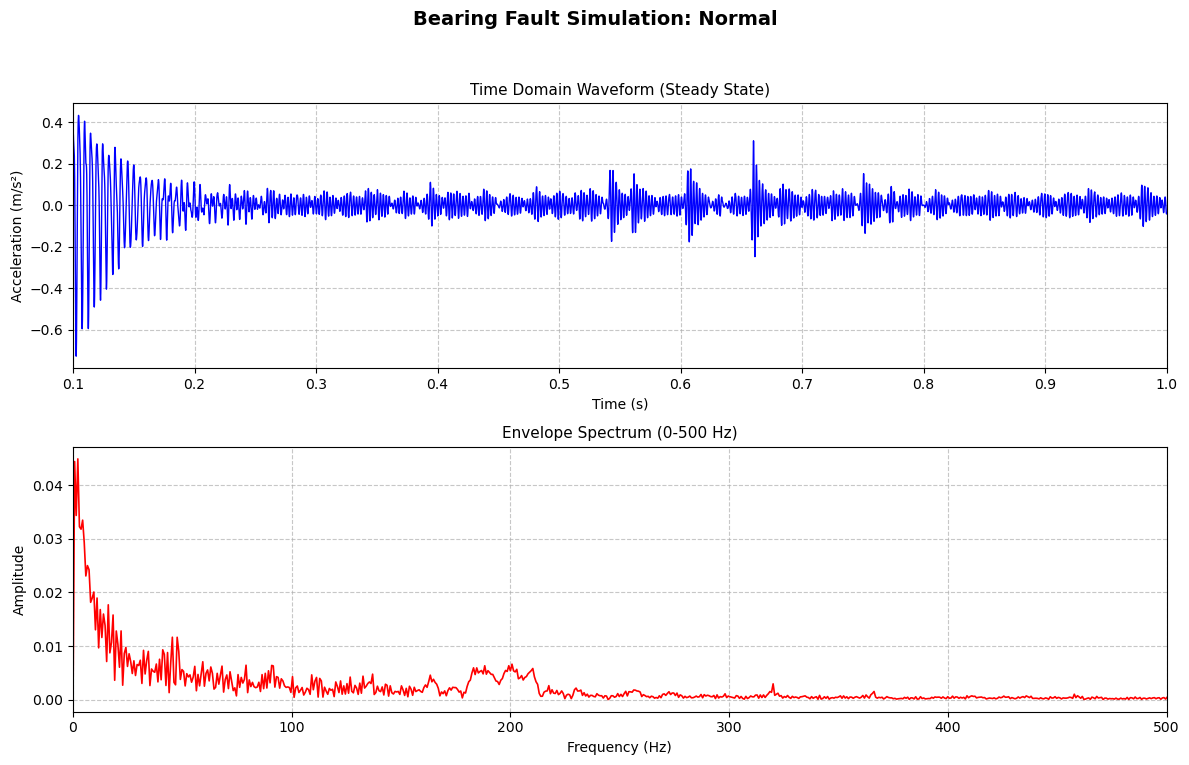

Plot saved: 'bearing_fault_normal.png' | All text elements in English


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.signal import hilbert

# ==================== Parameters ====================
def create_params(fault_type=0):
    p = {
        'Db': 6.746e-3, 'Dm': 28.5e-3, 'Nb': 8, 'alpha': 0.0, 'Cr': 2e-6,
        'min': 50.0, 'mout': 5.0, 'kin': 7.42e7, 'kout': 1.51e7,
        'cin': 1376.8, 'cout': 2210.7, 'Kc': 8.753e9,
        'g': 9.8, 'rpm': 1797, 'ws': 1797 * 2 * np.pi / 60,
        'fs': 12000, 'T': 1.0,
        'fault_type': fault_type,
        'defect_width': 3.6e-4, 'defect_depth': 1e-3
    }
    return p

# ==================== Core Functions (unchanged logic) ====================
def calculate_defect_Bj(t, theta_ball, p, gamma, wc):
    if p['fault_type'] == 0: return 0.0
    phi_o = (p['Dm'] + p['Db']) / 2
    phi_i = (p['Dm'] - p['Db']) / 2
    phi_b = p['Db'] / 2
    sagitta = phi_b - np.sqrt(max(0, phi_b**2 - (p['defect_width']/2)**2))
    C_val = min(sagitta, p['defect_depth'])
    
    if p['fault_type'] == 1:  # Outer race
        beta_o = np.arcsin(p['defect_width'] / (2 * phi_o))
        dist = np.abs(np.mod(theta_ball + np.pi, 2*np.pi) - np.pi)
        return C_val if dist < beta_o else 0.0
    elif p['fault_type'] == 2:  # Inner race
        beta_i = np.arcsin(p['defect_width'] / (2 * phi_i))
        rel_angle = np.mod(p['ws']*t - theta_ball + np.pi, 2*np.pi) - np.pi
        return C_val if np.abs(rel_angle) < beta_i else 0.0
    elif p['fault_type'] == 3:  # Ball
        beta_b = np.arcsin(p['defect_width'] / (2 * phi_b))
        wb = ((1 - gamma)*p['ws'] - wc) / gamma
        spin_angle = np.mod(((wc + wb)/2) * t, np.pi)
        if spin_angle > np.pi/2: spin_angle -= np.pi
        return C_val if np.abs(spin_angle) < beta_b else 0.0
    return 0.0

def bearing_dynamics_4dof(t, y, p):
    xin, vxin, yin, vyin, xout, vxout, yout, vyout = y
    gamma = p['Db'] / p['Dm']
    wc = (p['ws'] / 2) * (1 - gamma * np.cos(p['alpha']))
    FHX, FHY = 0.0, 0.0
    
    for j in range(p['Nb']):
        theta_curr = np.mod(wc * t + 2*np.pi*j/p['Nb'], 2*np.pi)
        Bj = calculate_defect_Bj(t, theta_curr, p, gamma, wc)
        delta = (xin-xout)*np.sin(theta_curr) + (yin-yout)*np.cos(theta_curr) - p['Cr'] - Bj
        if delta > 0:
            force = p['Kc'] * (delta**1.5)
            FHX += force * np.sin(theta_curr)
            FHY += force * np.cos(theta_curr)
    
    ax_in = (-FHX - p['cin']*vxin - p['kin']*xin) / p['min']
    ay_in = (-FHY - p['cin']*vyin - p['kin']*yin + p['min']*p['g']) / p['min']
    ax_out = (FHX - p['cout']*vxout - p['kout']*xout) / p['mout']
    ay_out = (FHY - p['cout']*vyout - p['kout']*yout + p['mout']*p['g']) / p['mout']
    return [vxin, ax_in, vyin, ay_in, vxout, ax_out, vyout, ay_out]

# ==================== Simulation & Visualization (ENGLISH ONLY) ====================
def simulate_and_plot(fault_type=2):
    p = create_params(fault_type)
    fault_labels = ['Normal', 'Outer Race Fault', 'Inner Race Fault', 'Ball Fault']
    print(f"Simulation started | Fault type: {fault_labels[fault_type]} (ID: {fault_type})")
    
    # Solve ODE
    t_eval = np.linspace(0, p['T'], int(p['T']*p['fs'])+1)
    sol = solve_ivp(lambda t,y: bearing_dynamics_4dof(t,y,p), 
                    [0, p['T']], np.zeros(8), t_eval=t_eval, 
                    rtol=1e-5, atol=1e-6, method='RK45')
    
    # Extract outer race Y-acceleration
    acc_y = np.array([bearing_dynamics_4dof(t, y, p)[7] for t, y in zip(sol.t, sol.y.T)])
    print("Simulation completed | Generating plots...")
    
    # Process signal (steady-state segment)
    cut_idx = int(len(sol.t)*0.1)
    t_valid, sig_valid = sol.t[cut_idx:], acc_y[cut_idx:]
    
    # Calculate theoretical frequencies
    gamma = p['Db']/p['Dm']
    fr = p['ws']/(2*np.pi)
    BPFO = (p['Nb']/2)*fr*(1 - gamma*np.cos(p['alpha']))
    BPFI = (p['Nb']/2)*fr*(1 + gamma*np.cos(p['alpha']))
    BSF  = fr*(p['Dm']/(2*p['Db']))*(1 - (gamma*np.cos(p['alpha']))**2)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), facecolor='white')
    fig.suptitle(f'Bearing Fault Simulation: {fault_labels[fault_type]}', fontsize=14, fontweight='bold')
    
    # Time domain
    ax1.plot(t_valid, sig_valid, 'b', linewidth=1)
    ax1.set_title('Time Domain Waveform (Steady State)', fontsize=11)
    ax1.set_xlabel('Time (s)'); ax1.set_ylabel('Acceleration (m/s²)')
    ax1.grid(True, linestyle='--', alpha=0.7)
    ax1.set_xlim([t_valid[0], t_valid[0] + 0.9])
    
    # Envelope spectrum
    env = np.abs(hilbert(sig_valid)) - np.mean(np.abs(hilbert(sig_valid)))
    NFFT = 2**int(np.ceil(np.log2(len(env))))
    fft_vals = np.fft.fft(env, NFFT)/len(env)
    freqs = p['fs']/2 * np.linspace(0, 1, NFFT//2+1)
    amp = 2*np.abs(fft_vals[:NFFT//2+1])
    
    ax2.plot(freqs, amp, 'r', linewidth=1.2, label='Envelope Spectrum')
    ax2.set_title('Envelope Spectrum (0-500 Hz)', fontsize=11)
    ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Amplitude')
    ax2.set_xlim([0, 500]); ax2.grid(True, linestyle='--', alpha=0.7)
    
    # Annotate characteristic frequencies
    legend_elements = [plt.Line2D([0], [0], color='r', lw=1.2, label='Simulated Signal')]
    if fault_type == 1:  # Outer race
        for f, lbl, style in [(BPFO, 'BPFO', '--'), (2*BPFO, '2×BPFO', ':')]:
            if f < 500: 
                ax2.axvline(f, color='k', linestyle=style, lw=1.5)
                ax2.text(f, max(amp)*0.85, lbl, rotation=90, va='top', ha='right', fontsize=9)
                legend_elements.append(plt.Line2D([0], [0], color='k', linestyle=style, lw=1.5, label=lbl))
    elif fault_type == 2:  # Inner race
        for f, lbl, style in [(BPFI, 'BPFI', '--'), (2*BPFI, '2×BPFI', ':'), (fr, 'fr', '-.')]:
            if f < 500:
                ax2.axvline(f, color='k' if 'BP' in lbl else 'b', linestyle=style, lw=1.5)
                ax2.text(f, max(amp)*0.85, lbl, rotation=90, va='top', ha='right', fontsize=9)
        for base in [BPFI, 2*BPFI]:
            for offset in [-fr, fr]:
                f_side = base + offset
                if 0 < f_side < 500:
                    ax2.axvline(f_side, color='g', linestyle='-.', lw=1.2)
        legend_elements += [
            plt.Line2D([0], [0], color='k', linestyle='--', lw=1.5, label='BPFI'),
            plt.Line2D([0], [0], color='k', linestyle=':', lw=1.5, label='2×BPFI'),
            plt.Line2D([0], [0], color='b', linestyle='-.', lw=1.5, label='Rotation Frequency (fr)'),
            plt.Line2D([0], [0], color='g', linestyle='-.', lw=1.2, label='Sidebands (±fr)')
        ]
    elif fault_type == 3:  # Ball
        for f, lbl, style in [(2*BSF, '2×BSF', '--'), (4*BSF, '4×BSF', ':')]:
            if f < 500:
                ax2.axvline(f, color='k', linestyle=style, lw=1.5)
                ax2.text(f, max(amp)*0.85, lbl, rotation=90, va='top', ha='right', fontsize=9)
                legend_elements.append(plt.Line2D([0], [0], color='k', linestyle=style, lw=1.5, label=lbl))
    
    if fault_type != 0:
        ax2.legend(handles=legend_elements, loc='upper right', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    filename = f'bearing_fault_{fault_labels[fault_type].replace(" ", "_").lower()}.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Plot saved: '{filename}' | All text elements in English")

# ==================== Run ====================
    # Change fault_type: 0=Normal, 1=Outer, 2=Inner, 3=Ball
simulate_and_plot(fault_type=0)

Simulation started | Fault type: Outer Race Fault (ID: 1)
Simulation completed | Generating plots...


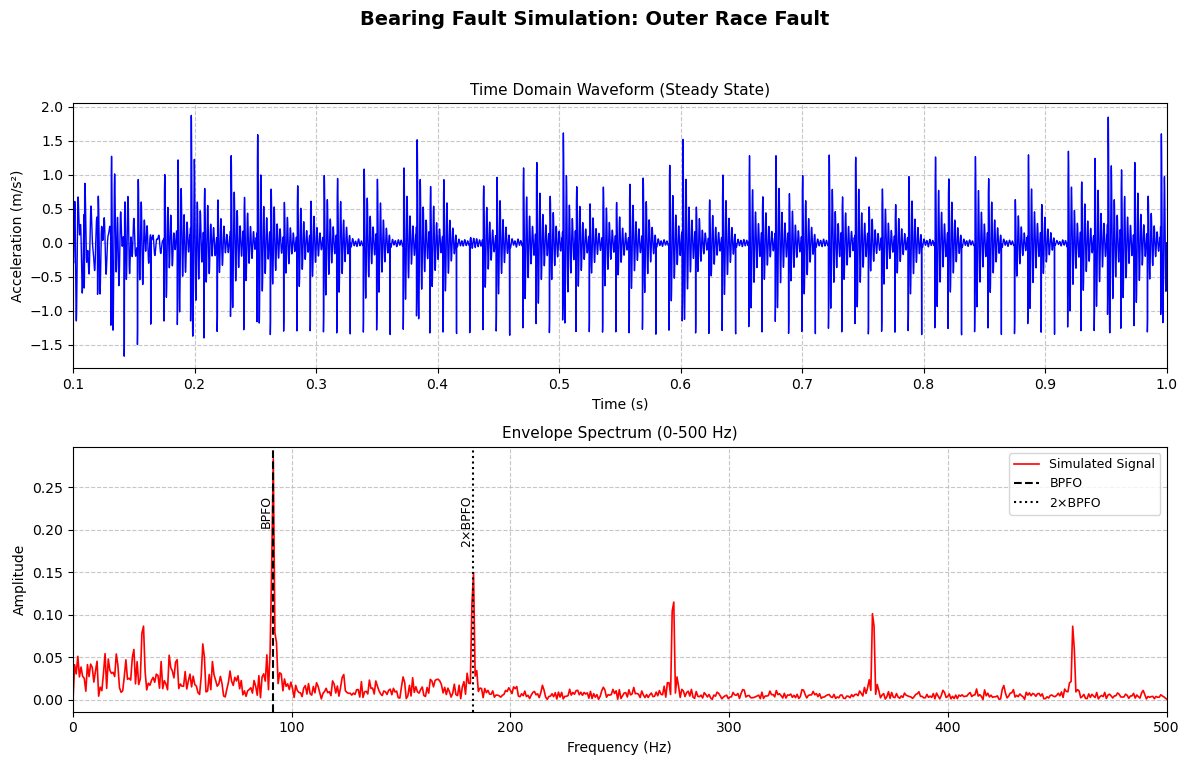

Plot saved: 'bearing_fault_outer_race_fault.png' | All text elements in English


In [9]:
simulate_and_plot(fault_type=1)

Simulation started | Fault type: Inner Race Fault (ID: 2)
Simulation completed | Generating plots...


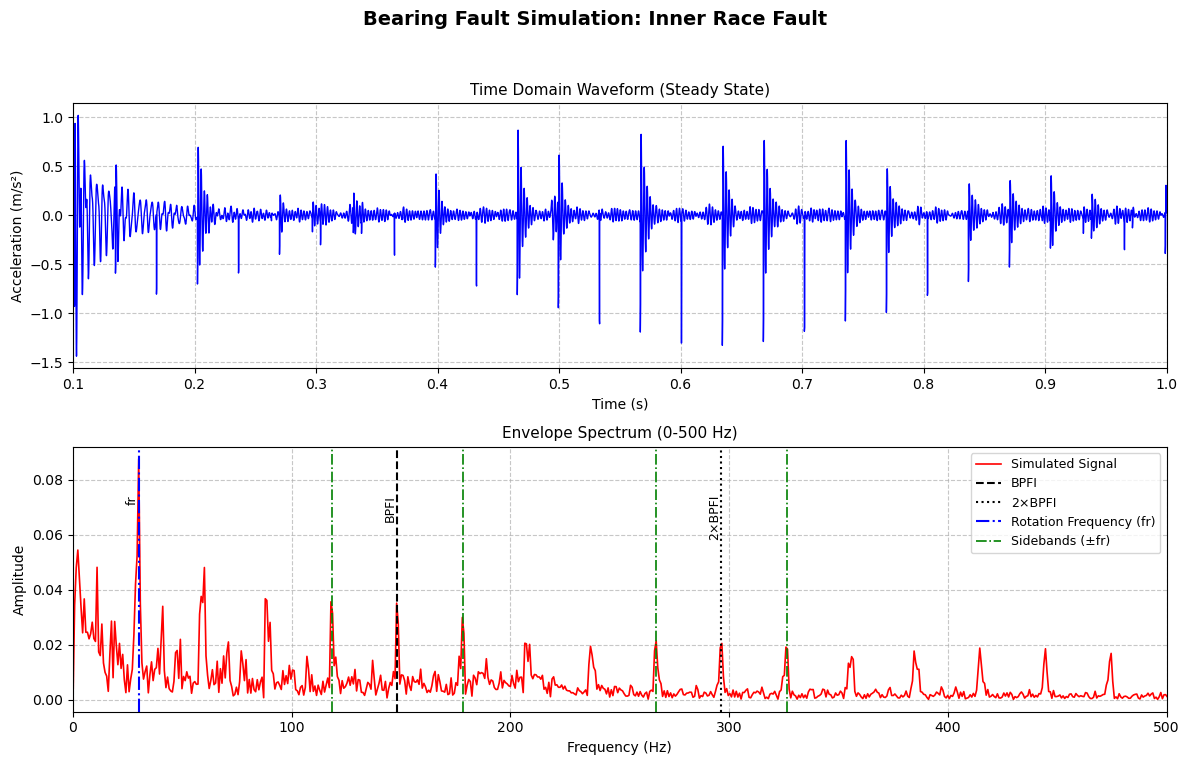

Plot saved: 'bearing_fault_inner_race_fault.png' | All text elements in English


In [10]:
simulate_and_plot(fault_type=2)

Simulation started | Fault type: Ball Fault (ID: 3)
Simulation completed | Generating plots...


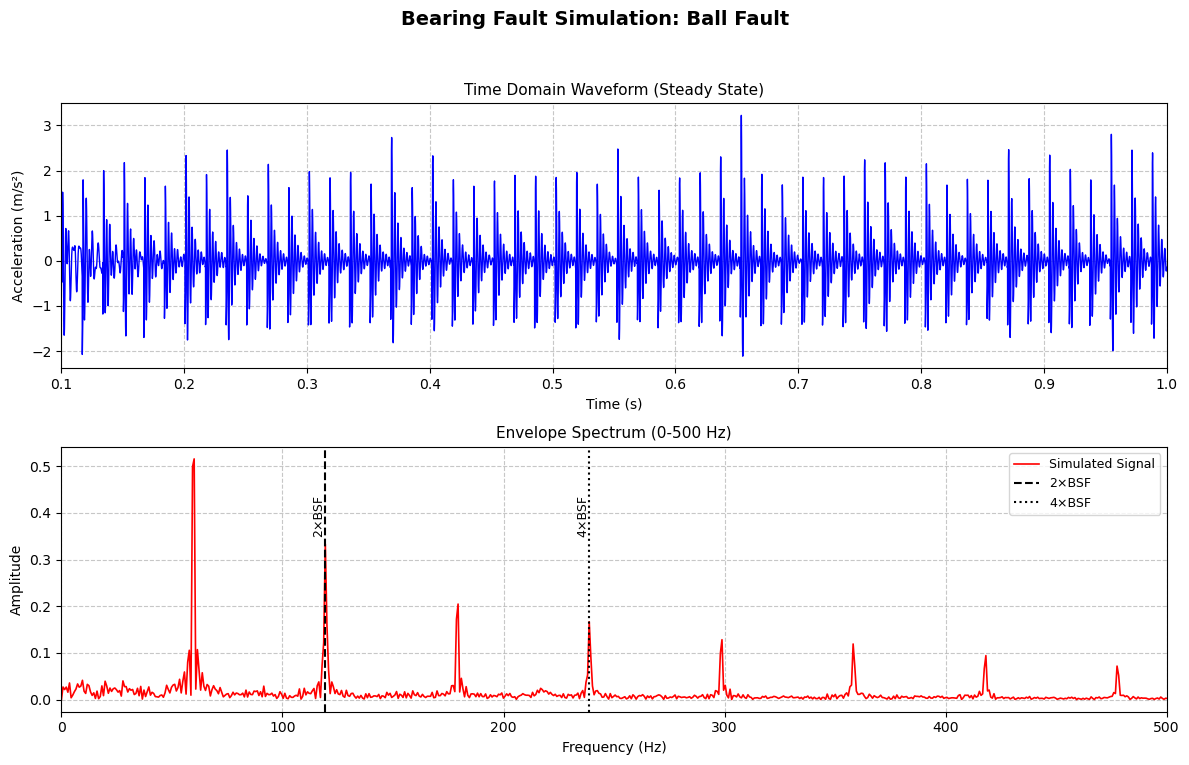

Plot saved: 'bearing_fault_ball_fault.png' | All text elements in English


In [11]:
simulate_and_plot(fault_type=3)